In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

In [2]:
df = pd.read_csv("activity-detection.csv")

In [4]:

print("Dataset Shape:", df.shape)


print("\nFirst 5 rows:")
df.head()

Dataset Shape: (10299, 563)

First 5 rows:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [6]:

print("Dataset Info:")
print(df.info())


print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nActivity Distribution:")
print(df['Activity'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 44.2+ MB
None

Missing Values:
0

Activity Distribution:
Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [7]:

X = df.drop('Activity', axis=1)
y = df['Activity']

print("Features (X) shape:", X.shape)
print("Target  (y) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features (X) shape: (10299, 562)
Target  (y) shape: (10299,)

Feature columns:
['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Y,2', 'tBodyAcc-arCoeff()-Y,3', 'tBodyAcc-arCoeff()-Y,4', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-arCoeff()-Z,2', 'tBodyAcc-arCoeff()-Z,3', 'tBodyAcc-arCoeff()-Z,4', 'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-X,Z', 'tBodyAcc-correlation()-Y,

In [8]:
# --------------------------------------------------------------------------
# First split  →  60% Train  |  40% Temp (Validation + Test)
# --------------------------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

# --------------------------------------------------------------------------
# Second split  →  Temp split equally into 20% Validation | 20% Test
# --------------------------------------------------------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# Print sizes
print("Split Summary:")
print(f"  Training set  : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples   ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set      : {X_test.shape[0]} samples   ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification – class-wise counts
print("\n Activity distribution per split:")
print(f"  Train :  {y_train.value_counts().sort_index().tolist()}")
print(f"  Val   :  {y_val.value_counts().sort_index().tolist()}")
print(f"  Test  :  {y_test.value_counts().sort_index().tolist()}")

Split Summary:
  Training set  : 6179 samples  (60.0%)
  Validation set: 2060 samples   (20.0%)
  Test set      : 2060 samples   (20.0%)

 Activity distribution per split:
  Train :  [1166, 1066, 1144, 1033, 844, 926]
  Val   :  [389, 355, 381, 345, 281, 309]
  Test  :  [389, 356, 381, 344, 281, 309]


In [9]:

train_df = pd.concat([X_train, y_train], axis=1)
val_df  = pd.concat([X_val,   y_val],   axis=1)
test_df = pd.concat([X_test,  y_test],  axis=1)

# Save to CSV
train_df.to_csv('ActivityTrain.csv',       index=False)
val_df.to_csv('ActivityValidation.csv',    index=False)
test_df.to_csv('ActivityTest.csv',         index=False)

print("CSV files saved successfully:")
print(f"  ✓ ActivityTrain.csv        – {train_df.shape}")
print(f"  ✓ ActivityValidation.csv   – {val_df.shape}")
print(f"  ✓ ActivityTest.csv         – {test_df.shape}")

CSV files saved successfully:
  ✓ ActivityTrain.csv        – (6179, 563)
  ✓ ActivityValidation.csv   – (2060, 563)
  ✓ ActivityTest.csv         – (2060, 563)


In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [11]:
traindf=pd.read_csv("ActivityTrain.csv")

In [14]:
numeric_df = traindf.select_dtypes(include='number')
numeric_df


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
0,0.321443,-0.023799,-0.119695,-0.336548,-0.183307,-0.154297,-0.396342,-0.224409,-0.220786,-0.073510,...,-0.172403,-0.563389,-0.874477,-0.684506,-0.948809,0.472612,-0.677946,0.256877,0.177768,24
1,0.217472,0.011115,-0.115445,-0.414603,-0.184887,-0.397835,-0.452784,-0.178431,-0.396061,-0.330133,...,-0.162583,-0.550507,0.571962,0.354293,0.925243,-0.287186,-0.755529,0.250761,0.092332,28
2,0.282537,-0.018321,-0.112263,-0.993073,-0.978583,-0.986129,-0.993825,-0.979682,-0.985791,-0.938877,...,-0.498477,-0.784398,0.033368,0.017298,0.038035,-0.109415,-0.313999,-0.206129,-0.337052,27
3,0.318016,-0.001377,-0.130748,-0.315958,0.073095,0.013274,-0.358730,0.092175,0.004789,-0.253829,...,0.233114,0.024109,-0.379363,0.516752,-0.010637,0.692445,-0.627893,0.262993,0.219719,13
4,0.276054,-0.015739,-0.108058,-0.997684,-0.994767,-0.991306,-0.998274,-0.993481,-0.991073,-0.941739,...,-0.681254,-0.898185,0.104284,0.066120,-0.069277,0.277116,-0.600329,-0.037652,-0.232059,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6174,0.301743,-0.010642,-0.126631,-0.978686,-0.964166,-0.957711,-0.981839,-0.969650,-0.960591,-0.901575,...,-0.264619,-0.678392,0.043469,0.418292,0.366083,0.354806,0.475201,-0.530643,-0.465368,3
6175,0.183580,-0.127213,-0.053418,0.066369,0.175940,-0.392213,0.024724,0.176251,-0.373970,0.026905,...,-0.285643,-0.649094,0.079392,-0.892303,0.939023,-0.067309,-0.779321,0.248037,0.046806,5
6176,0.410331,-0.033396,-0.146865,-0.050691,-0.034910,-0.121950,-0.126282,-0.069762,-0.068058,0.265577,...,-0.115772,-0.513698,-0.933418,-0.338748,-0.929130,0.180123,-0.573980,0.224409,0.292031,17
6177,0.174024,-0.037292,-0.105034,-0.394311,-0.143249,-0.460543,-0.478765,-0.168893,-0.411839,-0.180447,...,-0.387957,-0.757871,0.575137,-0.042192,-0.874889,0.316120,-0.772955,0.245910,-0.036525,4


In [29]:
# Standardization
scaler_std = StandardScaler()
standardized = scaler_std.fit_transform(numeric_df)

mean_before = numeric_df.mean()
std_before = numeric_df.std()

mean_after = standardized.mean(axis=0)
std_after = standardized.std(axis=0)

mean_before, std_before, mean_after, std_after

(tBodyAcc-mean()-X                        0.273662
 tBodyAcc-mean()-Y                       -0.018041
 tBodyAcc-mean()-Z                       -0.108637
 tBodyAcc-std()-X                        -0.609148
 tBodyAcc-std()-Y                        -0.510415
                                           ...    
 angle(tBodyGyroJerkMean,gravityMean)    -0.011796
 angle(X,gravityMean)                    -0.495876
 angle(Y,gravityMean)                     0.062510
 angle(Z,gravityMean)                    -0.053826
 subject                                 16.074446
 Length: 562, dtype: float64,
 tBodyAcc-mean()-X                       0.067604
 tBodyAcc-mean()-Y                       0.034959
 tBodyAcc-mean()-Z                       0.053206
 tBodyAcc-std()-X                        0.436875
 tBodyAcc-std()-Y                        0.499445
                                           ...   
 angle(tBodyGyroJerkMean,gravityMean)    0.484543
 angle(X,gravityMean)                    0.509204
 angle(Y,

In [17]:
df_std= pd.DataFrame(
    standardized,
    index=numeric_df.index
)
df_std.to_csv("ActivityScaledTrain.csv", index=False)

In [25]:
testdf=pd.read_csv("ActivityTest.csv")
valdf=pd.read_csv("ActivityValidation.csv")


In [26]:
numerictest_df = testdf.select_dtypes(include='number')
numericval_df = valdf.select_dtypes(include='number')

In [30]:
# Standardization
standardized = scaler_std.transform(numerictest_df)

mean_before = numerictest_df.mean()
std_before = numerictest_df.std()

mean_after = standardized.mean(axis=0)
std_after = standardized.std(axis=0)

mean_before, std_before, mean_after, std_after

(tBodyAcc-mean()-X                        0.275482
 tBodyAcc-mean()-Y                       -0.016648
 tBodyAcc-mean()-Z                       -0.110397
 tBodyAcc-std()-X                        -0.607711
 tBodyAcc-std()-Y                        -0.516176
                                           ...    
 angle(tBodyGyroJerkMean,gravityMean)     0.003415
 angle(X,gravityMean)                    -0.497292
 angle(Y,gravityMean)                     0.059930
 angle(Z,gravityMean)                    -0.058478
 subject                                 16.361165
 Length: 562, dtype: float64,
 tBodyAcc-mean()-X                       0.062998
 tBodyAcc-mean()-Y                       0.040224
 tBodyAcc-mean()-Z                       0.044110
 tBodyAcc-std()-X                        0.440633
 tBodyAcc-std()-Y                        0.497363
                                           ...   
 angle(tBodyGyroJerkMean,gravityMean)    0.487306
 angle(X,gravityMean)                    0.513879
 angle(Y,

In [32]:
df_std= pd.DataFrame(
    standardized,
    index=numerictest_df.index
)
df_std.to_csv("ActivityScaledTest.csv", index=False)

In [31]:
# Standardization

standardized = scaler_std.transform(numericval_df)

mean_before = numericval_df.mean()
std_before = numericval_df.std()

mean_after = standardized.mean(axis=0)
std_after = standardized.std(axis=0)

mean_before, std_before, mean_after, std_after

(tBodyAcc-mean()-X                        0.275270
 tBodyAcc-mean()-Y                       -0.017947
 tBodyAcc-mean()-Z                       -0.108317
 tBodyAcc-std()-X                        -0.603765
 tBodyAcc-std()-Y                        -0.503537
                                           ...    
 angle(tBodyGyroJerkMean,gravityMean)    -0.014123
 angle(X,gravityMean)                    -0.497692
 angle(Y,gravityMean)                     0.068815
 angle(Z,gravityMean)                    -0.051464
 subject                                 16.147573
 Length: 562, dtype: float64,
 tBodyAcc-mean()-X                       0.072033
 tBodyAcc-mean()-Y                       0.040101
 tBodyAcc-mean()-Z                       0.060202
 tBodyAcc-std()-X                        0.442369
 tBodyAcc-std()-Y                        0.505623
                                           ...   
 angle(tBodyGyroJerkMean,gravityMean)    0.482928
 angle(X,gravityMean)                    0.514514
 angle(Y,

In [33]:
df_std= pd.DataFrame(
    standardized,
    index=numericval_df.index
)
df_std.to_csv("ActivityScaledValidation.csv", index=False)

In [24]:
#pca

In [54]:
X = numeric_df.values
cov_matrix = np.cov(X, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

eigenvalues, eigenvectors

(array([ 7.59551662e+01+0.00000000e+00j,  3.32877265e+01+0.00000000e+00j,
         2.54949368e+00+0.00000000e+00j,  2.18478120e+00+0.00000000e+00j,
         9.91335287e-01+0.00000000e+00j,  9.03644191e-01+0.00000000e+00j,
         6.49447773e-01+0.00000000e+00j,  6.34535939e-01+0.00000000e+00j,
         5.92011714e-01+0.00000000e+00j,  5.19762907e-01+0.00000000e+00j,
         4.78063581e-01+0.00000000e+00j,  4.40298364e-01+0.00000000e+00j,
         3.71510719e-01+0.00000000e+00j,  3.48152187e-01+0.00000000e+00j,
         3.07138868e-01+0.00000000e+00j,  2.90583731e-01+0.00000000e+00j,
         2.70418609e-01+0.00000000e+00j,  2.55050055e-01+0.00000000e+00j,
         2.45761897e-01+0.00000000e+00j,  2.34804370e-01+0.00000000e+00j,
         2.27723643e-01+0.00000000e+00j,  2.22018832e-01+0.00000000e+00j,
         2.11049371e-01+0.00000000e+00j,  1.98678185e-01+0.00000000e+00j,
         1.90584398e-01+0.00000000e+00j,  1.85023113e-01+0.00000000e+00j,
         1.83468208e-01+0.00000000e+00

In [55]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[idx]


pca = PCA()
X_pca = pca.fit_transform(X)
er = pca.explained_variance_ratio_
print('Eigen values:',pca.explained_variance_)
print('explained variance ratio:', er)
print('Eigen vectors:', pca.components_)
cum_var = np.cumsum(er)
print('Cumulative variance:', cum_var)


Eigen values: [7.59551662e+01 3.32877265e+01 2.54949368e+00 2.18478120e+00
 9.91335287e-01 9.03644191e-01 6.49447773e-01 6.34535939e-01
 5.92011714e-01 5.19762907e-01 4.78063581e-01 4.40298364e-01
 3.71510719e-01 3.48152187e-01 3.07138868e-01 2.90583731e-01
 2.70418609e-01 2.55050055e-01 2.45761897e-01 2.34804370e-01
 2.27723643e-01 2.22018832e-01 2.11049371e-01 1.98678185e-01
 1.90584398e-01 1.85023113e-01 1.83468208e-01 1.67447388e-01
 1.61472932e-01 1.59217728e-01 1.54134745e-01 1.50996654e-01
 1.47477216e-01 1.42768119e-01 1.33999963e-01 1.29151630e-01
 1.24479143e-01 1.19111417e-01 1.17598983e-01 1.12043104e-01
 1.10413134e-01 1.07949361e-01 1.05247494e-01 1.01176945e-01
 1.00015910e-01 9.74369100e-02 9.23991998e-02 9.12739094e-02
 8.59397641e-02 8.52386720e-02 8.23673578e-02 7.87870129e-02
 7.67916677e-02 7.40881347e-02 7.31283864e-02 7.09544993e-02
 6.81032097e-02 6.62528666e-02 6.50143176e-02 6.36651176e-02
 6.31098898e-02 6.13222017e-02 6.03762466e-02 5.94348196e-02
 5.6638217

In [56]:
# Retain components with >=95% variance
n_components_95 = np.argmax(cum_var >= 0.95)+1
pca_95 = PCA(n_components=n_components_95)
X_reduced_95 = pca_95.fit_transform(X)

cov_reduced_95 = np.cov(X_reduced_95, rowvar=False)
cov_reduced_95

array([[ 7.59551662e+01, -1.65616954e-16,  5.29054157e-17,
         9.20094187e-18,  2.09321427e-16, -1.56416012e-16,
         1.56416012e-16,  9.54597719e-17,  1.78987072e-16,
        -2.96155316e-17,  2.42674842e-16, -3.79538852e-17,
         1.15011773e-17,  2.41524724e-17, -2.30023547e-17,
        -1.78268249e-17, -3.78820028e-17, -4.60047093e-18,
        -3.10531788e-17, -9.20094187e-18,  2.53025901e-17,
        -1.65329424e-17, -3.92477677e-17,  1.03510596e-17,
        -1.61016483e-17,  9.20094187e-18,  6.21063576e-17,
         2.87529433e-19, -6.90070640e-18],
       [-1.65616954e-16,  3.32877265e+01, -7.82080059e-17,
         1.67917189e-16,  5.06051803e-17, -4.83049448e-17,
         6.32564753e-18,  7.13072995e-17,  1.15011773e-17,
         8.85590655e-17,  1.02360478e-16,  1.12711538e-16,
         6.87195346e-17,  1.49515305e-17, -3.96431206e-17,
        -7.01571817e-17,  1.20762362e-17, -3.16282377e-18,
         4.88800037e-18, -2.30023547e-17, -4.29856503e-17,
        -1.46

In [57]:
df_reduced_95= pd.DataFrame(
    X_reduced_95,
    columns=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10', 'c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22','c23','c24','c25','c26','c27','c28','c29'],
    index=numeric_df.index
)
df_reduced_95.to_csv("ActivityPCAAllTrain.csv", index=False)

In [60]:
n_components = len(cum_var)
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X)
cov_reduced = np.cov(X_reduced, rowvar=False)
cov_reduced

array([[ 7.59551662e+01,  1.56416012e-15, -5.54356748e-16, ...,
        -1.90535510e-33,  6.38443594e-34, -2.23455258e-34],
       [ 1.56416012e-15,  3.32877265e+01,  1.87239167e-15, ...,
        -1.27050275e-32,  2.74530746e-33,  4.70852151e-34],
       [-5.54356748e-16,  1.87239167e-15,  2.54949368e+00, ...,
         2.55377438e-34,  6.28467913e-34,  3.76581964e-34],
       ...,
       [-1.90535510e-33, -1.27050275e-32,  2.55377438e-34, ...,
         2.05226194e-33, -9.12416728e-38, -3.80363393e-38],
       [ 6.38443594e-34,  2.74530746e-33,  6.28467913e-34, ...,
        -9.12416728e-38,  4.53839547e-34, -1.22365042e-38],
       [-2.23455258e-34,  4.70852151e-34,  3.76581964e-34, ...,
        -3.80363393e-38, -1.22365042e-38,  6.14260281e-35]])

In [62]:
df_reduced_95= pd.DataFrame(
    X_reduced,
    # columns=/['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10', 'c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22','c23','c24','c25','c26','c27','c28','c29'],
    index=numeric_df.index
)
df_reduced_95.to_csv("ActivityPCA95Train.csv", index=False)

In [63]:
X = numerictest_df.values
cov_matrix = np.cov(X, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

eigenvalues, eigenvectors

(array([ 7.49392093e+01+0.00000000e+00j,  3.31203694e+01+0.00000000e+00j,
         2.58127944e+00+0.00000000e+00j,  2.13722248e+00+0.00000000e+00j,
         9.75035439e-01+0.00000000e+00j,  8.76236462e-01+0.00000000e+00j,
         6.76601085e-01+0.00000000e+00j,  6.64156086e-01+0.00000000e+00j,
         5.86077359e-01+0.00000000e+00j,  5.13199413e-01+0.00000000e+00j,
         4.84725579e-01+0.00000000e+00j,  4.69040323e-01+0.00000000e+00j,
         3.61633573e-01+0.00000000e+00j,  3.44685521e-01+0.00000000e+00j,
         3.05834843e-01+0.00000000e+00j,  2.80529931e-01+0.00000000e+00j,
         2.74216411e-01+0.00000000e+00j,  2.59728913e-01+0.00000000e+00j,
         2.43400229e-01+0.00000000e+00j,  2.40300366e-01+0.00000000e+00j,
         2.17117450e-01+0.00000000e+00j,  2.14955075e-01+0.00000000e+00j,
         2.12089432e-01+0.00000000e+00j,  2.01481044e-01+0.00000000e+00j,
         1.92794012e-01+0.00000000e+00j,  1.81510334e-01+0.00000000e+00j,
         1.78109429e-01+0.00000000e+00

In [64]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[idx]

X_pca = pca.transform(X)
er = pca.explained_variance_ratio_
print('Eigen values:',pca.explained_variance_)
print('explained variance ratio:', er)
print('Eigen vectors:', pca.components_)
cum_var = np.cumsum(er)
print('Cumulative variance:', cum_var)


Eigen values: [7.59551662e+01 3.32877265e+01 2.54949368e+00 2.18478120e+00
 9.91335287e-01 9.03644191e-01 6.49447773e-01 6.34535939e-01
 5.92011714e-01 5.19762907e-01 4.78063581e-01 4.40298364e-01
 3.71510719e-01 3.48152187e-01 3.07138868e-01 2.90583731e-01
 2.70418609e-01 2.55050055e-01 2.45761897e-01 2.34804370e-01
 2.27723643e-01 2.22018832e-01 2.11049371e-01 1.98678185e-01
 1.90584398e-01 1.85023113e-01 1.83468208e-01 1.67447388e-01
 1.61472932e-01 1.59217728e-01 1.54134745e-01 1.50996654e-01
 1.47477216e-01 1.42768119e-01 1.33999963e-01 1.29151630e-01
 1.24479143e-01 1.19111417e-01 1.17598983e-01 1.12043104e-01
 1.10413134e-01 1.07949361e-01 1.05247494e-01 1.01176945e-01
 1.00015910e-01 9.74369100e-02 9.23991998e-02 9.12739094e-02
 8.59397641e-02 8.52386720e-02 8.23673578e-02 7.87870129e-02
 7.67916677e-02 7.40881347e-02 7.31283864e-02 7.09544993e-02
 6.81032097e-02 6.62528666e-02 6.50143176e-02 6.36651176e-02
 6.31098898e-02 6.13222017e-02 6.03762466e-02 5.94348196e-02
 5.6638217

In [65]:
# Retain components with >=95% variance
#n_components_95 = np.argmax(cum_var >= 0.95)+1
#pca_95 = PCA(n_components=n_components_95)
X_reduced_95 = pca_95.transform(X)

cov_reduced_95 = np.cov(X_reduced_95, rowvar=False)
cov_reduced_95

array([[ 7.48936497e+01,  1.11018256e+00, -5.28124916e-01,
        -6.46117006e-01,  1.37509363e-02,  3.80848788e-02,
        -2.81694800e-02,  1.33105367e-01,  1.71139206e-01,
         1.47398015e-01,  2.18278591e-02, -2.47139273e-01,
         7.27543687e-02, -1.54034499e-01, -4.78471172e-02,
         3.69925350e-02,  2.89536244e-02, -8.38758849e-02,
        -4.74357796e-02,  6.63656339e-02, -3.14107138e-02,
         6.01791547e-02,  4.99259211e-03,  5.46864024e-02,
        -1.65502803e-02,  6.88135649e-02, -6.19285337e-02,
        -3.08294229e-02,  5.55147810e-02],
       [ 1.11018256e+00,  3.31317238e+01, -3.92785249e-01,
         2.69350655e-01, -3.85250264e-02, -8.54887556e-02,
         1.47317597e-01,  1.92984238e-01,  1.94855170e-02,
        -4.33745671e-03, -2.26746671e-02,  2.73245996e-02,
         4.89593049e-02, -1.02671599e-01, -6.25861250e-02,
        -1.54681486e-01,  5.28859796e-02, -1.43781280e-01,
         1.30139385e-02, -3.48594574e-02,  7.22781527e-02,
        -1.49

In [66]:
df_reduced_95= pd.DataFrame(
    X_reduced_95,
    columns=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10', 'c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22','c23','c24','c25','c26','c27','c28','c29'],
    index=numerictest_df.index
)
df_reduced_95.to_csv("ActivityPCAAllTest.csv", index=False)

In [67]:
X_reduced = pca.transform(X)
cov_reduced = np.cov(X_reduced, rowvar=False)
cov_reduced

array([[ 7.48936497e+01,  1.11018256e+00, -5.28124916e-01, ...,
        -1.79254378e-16,  9.96219603e-17, -1.64372953e-16],
       [ 1.11018256e+00,  3.31317238e+01, -3.92785249e-01, ...,
        -7.57251221e-16,  3.41593316e-16, -3.59493424e-16],
       [-5.28124916e-01, -3.92785249e-01,  2.57636638e+00, ...,
        -1.55477506e-17, -1.52814631e-17, -1.10184787e-17],
       ...,
       [-1.79254378e-16, -7.57251221e-16, -1.55477506e-17, ...,
         2.52129866e-32, -7.44774503e-33,  9.59670214e-33],
       [ 9.96219603e-17,  3.41593316e-16, -1.52814631e-17, ...,
        -7.44774503e-33,  1.66603308e-32, -3.15729302e-33],
       [-1.64372953e-16, -3.59493424e-16, -1.10184787e-17, ...,
         9.59670214e-33, -3.15729302e-33,  1.66943363e-32]])

In [68]:
df_reduced_95= pd.DataFrame(
    X_reduced,
    # columns=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10', 'c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22','c23','c24','c25','c26','c27','c28','c29'],
    index=numerictest_df.index
)
df_reduced_95.to_csv("ActivityPCA95Test.csv", index=False)

In [69]:
X = numericval_df.values
cov_matrix = np.cov(X, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

eigenvalues, eigenvectors

(array([ 7.64087178e+01+0.00000000e+00j,  3.35345783e+01+0.00000000e+00j,
         2.71664442e+00+0.00000000e+00j,  2.20011879e+00+0.00000000e+00j,
         1.00449560e+00+0.00000000e+00j,  7.76044917e-01+0.00000000e+00j,
         6.75007375e-01+0.00000000e+00j,  6.37024829e-01+0.00000000e+00j,
         5.69635412e-01+0.00000000e+00j,  5.26959723e-01+0.00000000e+00j,
         5.00202053e-01+0.00000000e+00j,  4.64698674e-01+0.00000000e+00j,
         3.76638921e-01+0.00000000e+00j,  3.48619407e-01+0.00000000e+00j,
         3.30879338e-01+0.00000000e+00j,  2.95029175e-01+0.00000000e+00j,
         2.74242206e-01+0.00000000e+00j,  2.63009776e-01+0.00000000e+00j,
         2.42836259e-01+0.00000000e+00j,  2.35145763e-01+0.00000000e+00j,
         2.28678890e-01+0.00000000e+00j,  2.20763060e-01+0.00000000e+00j,
         2.12490125e-01+0.00000000e+00j,  2.04535245e-01+0.00000000e+00j,
         1.98106202e-01+0.00000000e+00j,  1.93160209e-01+0.00000000e+00j,
         1.81567976e-01+0.00000000e+00

In [70]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[idx]

X_pca = pca.transform(X)
er = pca.explained_variance_ratio_
print('Eigen values:',pca.explained_variance_)
print('explained variance ratio:', er)
print('Eigen vectors:', pca.components_)
cum_var = np.cumsum(er)
print('Cumulative variance:', cum_var)


Eigen values: [7.59551662e+01 3.32877265e+01 2.54949368e+00 2.18478120e+00
 9.91335287e-01 9.03644191e-01 6.49447773e-01 6.34535939e-01
 5.92011714e-01 5.19762907e-01 4.78063581e-01 4.40298364e-01
 3.71510719e-01 3.48152187e-01 3.07138868e-01 2.90583731e-01
 2.70418609e-01 2.55050055e-01 2.45761897e-01 2.34804370e-01
 2.27723643e-01 2.22018832e-01 2.11049371e-01 1.98678185e-01
 1.90584398e-01 1.85023113e-01 1.83468208e-01 1.67447388e-01
 1.61472932e-01 1.59217728e-01 1.54134745e-01 1.50996654e-01
 1.47477216e-01 1.42768119e-01 1.33999963e-01 1.29151630e-01
 1.24479143e-01 1.19111417e-01 1.17598983e-01 1.12043104e-01
 1.10413134e-01 1.07949361e-01 1.05247494e-01 1.01176945e-01
 1.00015910e-01 9.74369100e-02 9.23991998e-02 9.12739094e-02
 8.59397641e-02 8.52386720e-02 8.23673578e-02 7.87870129e-02
 7.67916677e-02 7.40881347e-02 7.31283864e-02 7.09544993e-02
 6.81032097e-02 6.62528666e-02 6.50143176e-02 6.36651176e-02
 6.31098898e-02 6.13222017e-02 6.03762466e-02 5.94348196e-02
 5.6638217

In [71]:
# Retain components with >=95% variance

X_reduced_95 = pca_95.transform(X)

cov_reduced_95 = np.cov(X_reduced_95, rowvar=False)
cov_reduced_95

array([[ 7.62612716e+01,  2.39986137e+00,  4.90124346e-02,
        -4.33703135e-01,  6.80634328e-02,  1.13620945e-01,
         1.78418138e-03,  3.30737238e-01, -1.43961691e-01,
         2.40453139e-01, -2.26833486e-01,  2.97798517e-02,
         1.67181869e-01, -3.41250916e-03, -7.55015422e-02,
        -1.55606216e-01, -2.07549145e-03, -6.36981337e-02,
        -5.93828697e-02,  1.07392728e-01,  8.04981267e-02,
         1.59219291e-01, -1.37487633e-01, -6.36091433e-02,
         5.97865364e-03, -8.49242340e-02,  6.33520989e-02,
         4.03032592e-02,  6.79607845e-02],
       [ 2.39986137e+00,  3.36535865e+01,  3.33248962e-01,
        -4.46134046e-02,  9.98913553e-04, -2.74961170e-01,
         9.29895391e-02,  1.03529009e-01,  9.90160900e-02,
         1.05436817e-01, -9.94879801e-02,  1.61555689e-01,
        -3.83598812e-02,  6.58073285e-02,  7.70632167e-02,
        -1.27819254e-02,  4.95476759e-03,  1.46670407e-01,
        -5.10480361e-03,  3.96649200e-02, -6.80073959e-02,
         3.09

In [72]:
df_reduced_95= pd.DataFrame(
    X_reduced_95,
    columns=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10', 'c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22','c23','c24','c25','c26','c27','c28','c29'],
    index=numericval_df.index
)
df_reduced_95.to_csv("ActivityPCAAllValidation.csv", index=False)

In [73]:
X_reduced = pca.transform(X)
cov_reduced = np.cov(X_reduced, rowvar=False)
cov_reduced

array([[ 7.62612716e+01,  2.39986137e+00,  4.90124346e-02, ...,
        -2.10606630e-16,  1.20056093e-16, -1.67434032e-16],
       [ 2.39986137e+00,  3.36535865e+01,  3.33248962e-01, ...,
        -7.82973793e-16,  3.38434621e-16, -4.02852749e-16],
       [ 4.90124346e-02,  3.33248962e-01,  2.68611574e+00, ...,
        -3.17404747e-17, -1.74275717e-17, -2.87817680e-17],
       ...,
       [-2.10606630e-16, -7.82973793e-16, -3.17404747e-17, ...,
         2.57629078e-32, -7.16242470e-33,  1.08205126e-32],
       [ 1.20056093e-16,  3.38434621e-16, -1.74275717e-17, ...,
        -7.16242470e-33,  1.82404720e-32, -2.58315940e-33],
       [-1.67434032e-16, -4.02852749e-16, -2.87817680e-17, ...,
         1.08205126e-32, -2.58315940e-33,  1.99326273e-32]])

In [74]:
df_reduced_95= pd.DataFrame(
    X_reduced,
    # columns=['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10', 'c11','c12','c13','c14','c15','c16','c17','c18','c19','c20','c21','c22','c23','c24','c25','c26','c27','c28','c29'],
    index=numericval_df.index
)
df_reduced_95.to_csv("ActivityPCA95Validation.csv", index=False)

In [75]:
#knn

In [88]:
# Load saved CSV files
train_data1 = pd.read_csv('ActivityTrain.csv')
val_data1   = pd.read_csv('ActivityValidation.csv')
test_data1  = pd.read_csv('ActivityTest.csv')

# ---------- Training ----------
X_train = train_data1.drop('Activity', axis=1)
y_train = train_data1['Activity']

# ---------- Validation ----------
X_val = val_data1.drop('Activity', axis=1)
y_val = val_data1['Activity']

# ---------- Test ----------
X_test = test_data1.drop('Activity', axis=1)
y_test = test_data1['Activity']

print("Data loaded from CSV files:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")

Data loaded from CSV files:
  Train : (6179, 562)
  Val   : (2060, 562)
  Test  : (2060, 562)


In [89]:
# K values to evaluate
k_values = [1, 5, 7, 9, 11, 13]

# List to store results for every K
validation_results = []

print("KNN – Validation Results")
print("=" * 80)

for k in k_values:
    # ----- Train -----
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # ----- Predict on Validation -----
    y_val_pred = knn.predict(X_val)

    # ----- Compute all metrics -----
    acc            = accuracy_score(y_val, y_val_pred)
    prec_micro     = precision_score(y_val, y_val_pred, average='micro')
    prec_macro     = precision_score(y_val, y_val_pred, average='macro')
    rec_micro      = recall_score(y_val, y_val_pred,    average='micro')
    rec_macro      = recall_score(y_val, y_val_pred,    average='macro')
    f1_micro       = f1_score(y_val, y_val_pred,        average='micro')
    f1_macro       = f1_score(y_val, y_val_pred,        average='macro')

    # Store in list
    validation_results.append({
        'K'              : k,
        'Accuracy'       : acc,
        'Precision_Micro': prec_micro,
        'Precision_Macro': prec_macro,
        'Recall_Micro'   : rec_micro,
        'Recall_Macro'   : rec_macro,
        'F1_Micro'       : f1_micro,
        'F1_Macro'       : f1_macro
    })

    print(f"  K = {k:2d}  |  Accuracy: {acc:.4f}  |  "
          f"Prec(M): {prec_macro:.4f}  |  "
          f"Rec(M): {rec_macro:.4f}  |  "
          f"F1(M): {f1_macro:.4f}")

print("=" * 80)

KNN – Validation Results
  K =  1  |  Accuracy: 0.9680  |  Prec(M): 0.9698  |  Rec(M): 0.9692  |  F1(M): 0.9695
  K =  5  |  Accuracy: 0.9650  |  Prec(M): 0.9669  |  Rec(M): 0.9657  |  F1(M): 0.9661
  K =  7  |  Accuracy: 0.9636  |  Prec(M): 0.9658  |  Rec(M): 0.9645  |  F1(M): 0.9650
  K =  9  |  Accuracy: 0.9563  |  Prec(M): 0.9592  |  Rec(M): 0.9571  |  F1(M): 0.9577
  K = 11  |  Accuracy: 0.9587  |  Prec(M): 0.9618  |  Rec(M): 0.9594  |  F1(M): 0.9601
  K = 13  |  Accuracy: 0.9515  |  Prec(M): 0.9554  |  Rec(M): 0.9522  |  F1(M): 0.9530


In [90]:
# Convert results list to a DataFrame
val_results_df = pd.DataFrame(validation_results)

# Round values for clean display
display_df = val_results_df.copy()
display_df.iloc[:, 1:] = display_df.iloc[:, 1:].round(4)

print("Complete Validation Metrics for All K Values:")
print()
print(display_df.to_string(index=False))

Complete Validation Metrics for All K Values:

 K  Accuracy  Precision_Micro  Precision_Macro  Recall_Micro  Recall_Macro  F1_Micro  F1_Macro
 1    0.9680           0.9680           0.9698        0.9680        0.9692    0.9680    0.9695
 5    0.9650           0.9650           0.9669        0.9650        0.9657    0.9650    0.9661
 7    0.9636           0.9636           0.9658        0.9636        0.9645    0.9636    0.9650
 9    0.9563           0.9563           0.9592        0.9563        0.9571    0.9563    0.9577
11    0.9587           0.9587           0.9618        0.9587        0.9594    0.9587    0.9601
13    0.9515           0.9515           0.9554        0.9515        0.9522    0.9515    0.9530


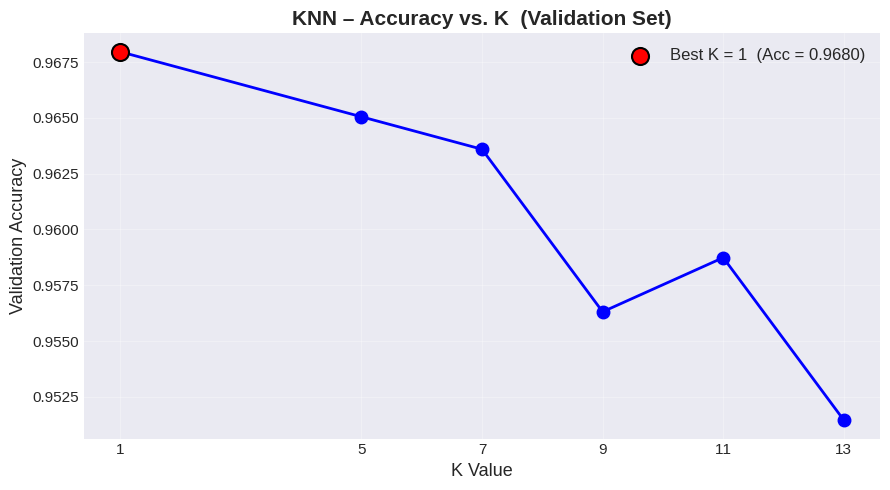

Best K selected from validation: 1  (Accuracy = 0.9680)


In [91]:
# Identify the best K
best_idx       = val_results_df['Accuracy'].idxmax()
best_k         = int(val_results_df.loc[best_idx, 'K'])
best_val_acc   = val_results_df.loc[best_idx, 'Accuracy']

# ---------- Plot ----------
plt.figure(figsize=(9, 5))

plt.plot(val_results_df['K'], val_results_df['Accuracy'],
         'bo-', linewidth=2, markersize=9, zorder=3)

# Highlight best K
plt.scatter([best_k], [best_val_acc],
            color='red', s=150, edgecolors='black',
            linewidths=1.5, zorder=4,
            label=f'Best K = {best_k}  (Acc = {best_val_acc:.4f})')

plt.xlabel('K Value', fontsize=13)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.title('KNN – Accuracy vs. K  (Validation Set)', fontsize=15, fontweight='bold')
plt.xticks(k_values, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('accuracy_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best K selected from validation: {best_k}  (Accuracy = {best_val_acc:.4f})")

In [92]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Predict on the test set  (used ONLY here)
y_test_pred = knn_final.predict(X_test)

print(f"Predictions generated for {len(y_test_pred)} test samples using best K")# ---------- Compute every required metric ----------
test_acc        = accuracy_score(y_test, y_test_pred)
test_prec_micro = precision_score(y_test, y_test_pred, average='micro')
test_prec_macro = precision_score(y_test, y_test_pred, average='macro')
test_rec_micro  = recall_score(y_test, y_test_pred,    average='micro')
test_rec_macro  = recall_score(y_test, y_test_pred,    average='macro')
test_f1_micro   = f1_score(y_test, y_test_pred,        average='micro')
test_f1_macro   = f1_score(y_test, y_test_pred,        average='macro')

# ---------- Print ----------
print("=" * 50)
print("  TEST SET RESULTS")
print(f"  Best K  =  {best_k}")
print("=" * 50)
print(f"  Accuracy          :  {test_acc:.4f}")
print("-" * 50)
print(f"  Precision (Micro) :  {test_prec_micro:.4f}")
print(f"  Precision (Macro) :  {test_prec_macro:.4f}")
print("-" * 50)
print(f"  Recall    (Micro) :  {test_rec_micro:.4f}")
print(f"  Recall    (Macro) :  {test_rec_macro:.4f}")
print("-" * 50)
print(f"  F1-Score  (Micro) :  {test_f1_micro:.4f}")
print(f"  F1-Score  (Macro) :  {test_f1_macro:.4f}")
print("=" * 50)

Predictions generated for 2060 test samples using best K
  TEST SET RESULTS
  Best K  =  1
  Accuracy          :  0.9757
--------------------------------------------------
  Precision (Micro) :  0.9757
  Precision (Macro) :  0.9773
--------------------------------------------------
  Recall    (Micro) :  0.9757
  Recall    (Macro) :  0.9770
--------------------------------------------------
  F1-Score  (Micro) :  0.9757
  F1-Score  (Macro) :  0.9771


In [93]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Get unique class labels (sorted) for display
class_labels = sorted(y_test.unique())

# Wrap in a DataFrame so row/column labels show up
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
cm_df.index.name   = 'True \\ Predicted'

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
                    LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
True \ Predicted                                                             
LAYING                 389        0         0        0                   0   
SITTING                  0      331        25        0                   0   
STANDING                 0       22       359        0                   0   
WALKING                  0        0         0      343                   0   
WALKING_DOWNSTAIRS       0        0         0        2                 279   
WALKING_UPSTAIRS         0        0         0        0                   0   

                    WALKING_UPSTAIRS  
True \ Predicted                      
LAYING                             0  
SITTING                            0  
STANDING                           0  
WALKING                            1  
WALKING_DOWNSTAIRS                 0  
WALKING_UPSTAIRS                 309  


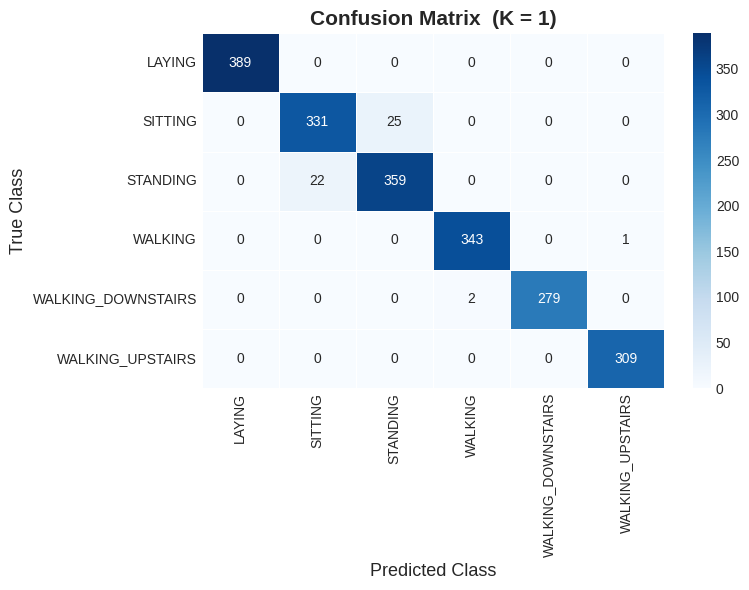

In [94]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cbar=True, linewidths=0.5)

plt.xlabel('Predicted Class', fontsize=13)
plt.ylabel('True Class',      fontsize=13)
plt.title(f'Confusion Matrix  (K = {best_k})', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [96]:
# Load saved CSV files
train_data = pd.read_csv('ActivityScaledTrain.csv')
val_data   = pd.read_csv('ActivityScaledValidation.csv')
test_data  = pd.read_csv('ActivityScaledTest.csv')

# ---------- Training ----------
X_train = train_data
y_train = train_data1['Activity']

# ---------- Validation ----------
X_val = val_data
y_val = train_data1['Activity']

# ---------- Test ----------
X_test = test_data
y_test = train_data1['Activity']

print("Data loaded from CSV files:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")

Data loaded from CSV files:
  Train : (6179, 562)
  Val   : (2060, 562)
  Test  : (2060, 562)


In [97]:
# K values to evaluate
k_values = [1, 5, 7, 9, 11, 13]

# List to store results for every K
validation_results = []

print("KNN – Validation Results")
print("=" * 80)

for k in k_values:
    # ----- Train -----
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # ----- Predict on Validation -----
    y_val_pred = knn.predict(X_val)

    # ----- Compute all metrics -----
    acc            = accuracy_score(y_val, y_val_pred)
    prec_micro     = precision_score(y_val, y_val_pred, average='micro')
    prec_macro     = precision_score(y_val, y_val_pred, average='macro')
    rec_micro      = recall_score(y_val, y_val_pred,    average='micro')
    rec_macro      = recall_score(y_val, y_val_pred,    average='macro')
    f1_micro       = f1_score(y_val, y_val_pred,        average='micro')
    f1_macro       = f1_score(y_val, y_val_pred,        average='macro')

    # Store in list
    validation_results.append({
        'K'              : k,
        'Accuracy'       : acc,
        'Precision_Micro': prec_micro,
        'Precision_Macro': prec_macro,
        'Recall_Micro'   : rec_micro,
        'Recall_Macro'   : rec_macro,
        'F1_Micro'       : f1_micro,
        'F1_Macro'       : f1_macro
    })

    print(f"  K = {k:2d}  |  Accuracy: {acc:.4f}  |  "
          f"Prec(M): {prec_macro:.4f}  |  "
          f"Rec(M): {rec_macro:.4f}  |  "
          f"F1(M): {f1_macro:.4f}")

print("=" * 80)

KNN – Validation Results


ValueError: Found input variables with inconsistent numbers of samples: [6179, 2060]

In [98]:
# Convert results list to a DataFrame
val_results_df = pd.DataFrame(validation_results)

# Round values for clean display
display_df = val_results_df.copy()
display_df.iloc[:, 1:] = display_df.iloc[:, 1:].round(4)

print("Complete Validation Metrics for All K Values:")
print()
print(display_df.to_string(index=False))

Complete Validation Metrics for All K Values:

Empty DataFrame
Columns: []
Index: []


In [99]:
# Identify the best K
best_idx       = val_results_df['Accuracy'].idxmax()
best_k         = int(val_results_df.loc[best_idx, 'K'])
best_val_acc   = val_results_df.loc[best_idx, 'Accuracy']

# ---------- Plot ----------
plt.figure(figsize=(9, 5))

plt.plot(val_results_df['K'], val_results_df['Accuracy'],
         'bo-', linewidth=2, markersize=9, zorder=3)

# Highlight best K
plt.scatter([best_k], [best_val_acc],
            color='red', s=150, edgecolors='black',
            linewidths=1.5, zorder=4,
            label=f'Best K = {best_k}  (Acc = {best_val_acc:.4f})')

plt.xlabel('K Value', fontsize=13)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.title('KNN – Accuracy vs. K  (Validation Set)', fontsize=15, fontweight='bold')
plt.xticks(k_values, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('accuracy_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best K selected from validation: {best_k}  (Accuracy = {best_val_acc:.4f})")

KeyError: 'Accuracy'

In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Predict on the test set  (used ONLY here)
y_test_pred = knn_final.predict(X_test)

print(f"Predictions generated for {len(y_test_pred)} test samples using best K")# ---------- Compute every required metric ----------
test_acc        = accuracy_score(y_test, y_test_pred)
test_prec_micro = precision_score(y_test, y_test_pred, average='micro')
test_prec_macro = precision_score(y_test, y_test_pred, average='macro')
test_rec_micro  = recall_score(y_test, y_test_pred,    average='micro')
test_rec_macro  = recall_score(y_test, y_test_pred,    average='macro')
test_f1_micro   = f1_score(y_test, y_test_pred,        average='micro')
test_f1_macro   = f1_score(y_test, y_test_pred,        average='macro')

# ---------- Print ----------
print("=" * 50)
print("  TEST SET RESULTS")
print(f"  Best K  =  {best_k}")
print("=" * 50)
print(f"  Accuracy          :  {test_acc:.4f}")
print("-" * 50)
print(f"  Precision (Micro) :  {test_prec_micro:.4f}")
print(f"  Precision (Macro) :  {test_prec_macro:.4f}")
print("-" * 50)
print(f"  Recall    (Micro) :  {test_rec_micro:.4f}")
print(f"  Recall    (Macro) :  {test_rec_macro:.4f}")
print("-" * 50)
print(f"  F1-Score  (Micro) :  {test_f1_micro:.4f}")
print(f"  F1-Score  (Macro) :  {test_f1_macro:.4f}")
print("=" * 50)

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Get unique class labels (sorted) for display
class_labels = sorted(y_test.unique())

# Wrap in a DataFrame so row/column labels show up
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
cm_df.index.name   = 'True \\ Predicted'

print("Confusion Matrix:")
print(cm_df)

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cbar=True, linewidths=0.5)

plt.xlabel('Predicted Class', fontsize=13)
plt.ylabel('True Class',      fontsize=13)
plt.title(f'Confusion Matrix  (K = {best_k})', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()